# F1 Sponsor Stock Return Analysis

This notebook is written for the current project structure:

```text
F1-SPONSOR-STOCKS/
├── data/
│   ├── constructor_results.csv
│   ├── constructor_standings.csv
│   ├── constructors.csv
│   ├── qualifying.csv
│   ├── races.csv
│   ├── results.csv
│   └── sprint_results.csv
├── sponsor_mapping.xlsx
├── requirements.txt
└── f1_sponsor_analysis.ipynb
```

The goal is to build a clean race-by-team dataset, merge it with sponsor tickers, download Yahoo Finance data, and prepare a regression-ready dataset.


In [36]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm

warnings.filterwarnings("ignore")

START_YEAR = 2021
END_YEAR = 2025

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MAPPING_FILE = PROJECT_ROOT / "sponsor_mapping.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR.resolve())
print("Sponsor mapping file:", MAPPING_FILE.resolve())
print("Data directory exists:", DATA_DIR.exists())
print("Sponsor mapping exists:", MAPPING_FILE.exists())

Project root: /Users/wayne/Desktop/Exchange/f1-sponsor-stocks
Data directory: /Users/wayne/Desktop/Exchange/f1-sponsor-stocks/data
Sponsor mapping file: /Users/wayne/Desktop/Exchange/f1-sponsor-stocks/sponsor_mapping.xlsx
Data directory exists: True
Sponsor mapping exists: True


## 1. Load the local CSV files

The code below reads the CSV files directly from the `data/` folder. It does not use a `data["races"]` dictionary, because your local project stores each file as a normal CSV file inside the `data` folder.


In [37]:
required_files = {
    "races": "races.csv",
    "results": "results.csv",
    "constructors": "constructors.csv",
    "constructor_results": "constructor_results.csv",
    "constructor_standings": "constructor_standings.csv",
    "qualifying": "qualifying.csv",
    "sprint_results": "sprint_results.csv",
}

missing_files = [filename for filename in required_files.values() if not (DATA_DIR / filename).exists()]
if missing_files:
    raise FileNotFoundError(
        "The following files are missing from the data/ folder: " + ", ".join(missing_files)
    )

races = pd.read_csv(DATA_DIR / "races.csv")
results = pd.read_csv(DATA_DIR / "results.csv")
constructors = pd.read_csv(DATA_DIR / "constructors.csv")
constructor_results = pd.read_csv(DATA_DIR / "constructor_results.csv")
constructor_standings = pd.read_csv(DATA_DIR / "constructor_standings.csv")
qualifying = pd.read_csv(DATA_DIR / "qualifying.csv")
sprint_results = pd.read_csv(DATA_DIR / "sprint_results.csv")

loaded_frames = {
    "races": races,
    "results": results,
    "constructors": constructors,
    "constructor_results": constructor_results,
    "constructor_standings": constructor_standings,
    "qualifying": qualifying,
    "sprint_results": sprint_results,
}

for name, df in loaded_frames.items():
    print(f"{name:25s} shape = {df.shape}")
    print("Columns:", list(df.columns))
    print("-" * 100)

races                     shape = (1171, 18)
Columns: ['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time']
----------------------------------------------------------------------------------------------------
results                   shape = (27392, 18)
Columns: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId']
----------------------------------------------------------------------------------------------------
constructors              shape = (214, 5)
Columns: ['constructorId', 'constructorRef', 'name', 'nationality', 'url']
----------------------------------------------------------------------------------------------------
constructor_results       shape = (12942

## 2. Standardize column names when needed

Some Formula 1 datasets use Ergast-style names such as `raceId`, `constructorId`, and `year`. Other versions use `race_id`, `constructor_id`, and `season`. This section standardizes the key columns so the rest of the notebook works with either version.


In [38]:
def standardize_f1_tables(races, results, constructors, constructor_results, constructor_standings, qualifying, sprint_results):
    races = races.copy()
    results = results.copy()
    constructors = constructors.copy()
    constructor_results = constructor_results.copy()
    constructor_standings = constructor_standings.copy()
    qualifying = qualifying.copy()
    sprint_results = sprint_results.copy()

    # races.csv
    races = races.rename(columns={
        "race_id": "raceId",
        "season": "year",
        "race_name": "race_name",
    })
    if "name" in races.columns and "race_name" not in races.columns:
        races = races.rename(columns={"name": "race_name"})
    if "raceId" not in races.columns or "year" not in races.columns:
        raise KeyError("races.csv must contain either raceId/year or race_id/season.")

    # results.csv
    results = results.rename(columns={
        "result_id": "resultId",
        "race_id": "raceId",
        "driver_id": "driverId",
        "constructor_id": "constructorId",
        "position_order": "positionOrder",
    })
    if "raceId" not in results.columns or "constructorId" not in results.columns:
        raise KeyError("results.csv must contain either raceId/constructorId or race_id/constructor_id.")

    # constructors.csv
    constructors = constructors.rename(columns={
        "constructor_id": "constructorRef",
        "constructor_ref": "constructorRef",
        "constructorId": "constructorId",
    })
    if "constructorId" not in constructors.columns:
        # Some cleaned datasets only have constructorRef-like identifiers. In that case, use them as the key.
        if "constructorRef" in constructors.columns:
            constructors["constructorId"] = constructors["constructorRef"]
        else:
            raise KeyError("constructors.csv must contain constructorId or constructor_id.")
    if "constructorRef" not in constructors.columns:
        constructors["constructorRef"] = constructors["constructorId"]
    if "name" not in constructors.columns:
        raise KeyError("constructors.csv must contain a name column.")

    # constructor_results.csv
    constructor_results = constructor_results.rename(columns={
        "constructor_results_id": "constructorResultsId",
        "race_id": "raceId",
        "constructor_id": "constructorId",
    })

    # constructor_standings.csv
    constructor_standings = constructor_standings.rename(columns={
        "constructor_standings_id": "constructorStandingsId",
        "race_id": "raceId",
        "constructor_id": "constructorId",
    })

    # qualifying.csv
    qualifying = qualifying.rename(columns={
        "qualify_id": "qualifyId",
        "race_id": "raceId",
        "driver_id": "driverId",
        "constructor_id": "constructorId",
    })

    # sprint_results.csv
    sprint_results = sprint_results.rename(columns={
        "result_id": "resultId",
        "race_id": "raceId",
        "driver_id": "driverId",
        "constructor_id": "constructorId",
        "position_order": "positionOrder",
    })

    # Harmonize key dtypes for safer merges.
    for df in [races, results, constructor_results, constructor_standings, qualifying, sprint_results]:
        if "raceId" in df.columns:
            df["raceId"] = df["raceId"].astype(str)
        if "constructorId" in df.columns:
            df["constructorId"] = df["constructorId"].astype(str)
    constructors["constructorId"] = constructors["constructorId"].astype(str)
    constructors["constructorRef"] = constructors["constructorRef"].astype(str)

    races["date"] = pd.to_datetime(races["date"], errors="coerce")
    races["year"] = pd.to_numeric(races["year"], errors="coerce").astype("Int64")

    return races, results, constructors, constructor_results, constructor_standings, qualifying, sprint_results

(
    races,
    results,
    constructors,
    constructor_results,
    constructor_standings,
    qualifying,
    sprint_results,
) = standardize_f1_tables(
    races, results, constructors, constructor_results, constructor_standings, qualifying, sprint_results
)

print("Standardization completed.")
print("races columns:", list(races.columns))
print("constructors columns:", list(constructors.columns))

Standardization completed.
races columns: ['raceId', 'year', 'round', 'circuitId', 'race_name', 'date', 'time', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time']
constructors columns: ['constructorId', 'constructorRef', 'name', 'nationality', 'url']


## 3. Check race result coverage for 2021–2025

Before doing any finance analysis, we first check whether the F1 race data has race results for the selected sample period.


In [39]:
recent_races = races[races["year"].between(START_YEAR, END_YEAR)].copy()

coverage = (
    recent_races.assign(has_results=recent_races["raceId"].isin(results["raceId"].unique()))
    .groupby(["year", "has_results"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={False: "races_without_results", True: "races_with_results"})
)

for col in ["races_without_results", "races_with_results"]:
    if col not in coverage.columns:
        coverage[col] = 0

coverage["total_races_in_races_csv"] = coverage["races_without_results"] + coverage["races_with_results"]
coverage["result_coverage_rate"] = coverage["races_with_results"] / coverage["total_races_in_races_csv"]
coverage

has_results,races_with_results,races_without_results,total_races_in_races_csv,result_coverage_rate
year,,,,
2021,22,0,22,1.0
2022,22,0,22,1.0
2023,22,0,22,1.0
2024,24,0,24,1.0
2025,24,0,24,1.0


## 4. Build a race-by-team performance dataset

Each row will represent one constructor in one race. This is the key F1 performance table that will later be linked to sponsor companies.


In [40]:
# Constructor-level race points from constructor_results.csv.
team_race_points = (
    constructor_results
    .merge(recent_races[["raceId", "year", "round", "race_name", "date"]], on="raceId", how="inner")
    .merge(constructors[["constructorId", "constructorRef", "name", "nationality"]], on="constructorId", how="left")
    .rename(columns={
        "name": "team",
        "points": "team_points_constructor_results",
    })
)

# Driver results are used to identify wins, podiums, and best finishing position.
required_result_cols = ["raceId", "constructorId", "positionOrder", "points"]
missing_result_cols = [col for col in required_result_cols if col not in results.columns]
if missing_result_cols:
    raise KeyError(f"results.csv is missing required columns: {missing_result_cols}")

results_for_recent_races = results.merge(
    recent_races[["raceId", "year", "round", "race_name", "date"]],
    on="raceId",
    how="inner",
)
results_for_recent_races["positionOrder"] = pd.to_numeric(results_for_recent_races["positionOrder"], errors="coerce")
results_for_recent_races["points"] = pd.to_numeric(results_for_recent_races["points"], errors="coerce")

team_performance = (
    results_for_recent_races
    .groupby(["raceId", "constructorId"], as_index=False)
    .agg(
        best_finish=("positionOrder", "min"),
        team_points_from_results=("points", "sum"),
        number_of_classified_drivers=("driverId", "count") if "driverId" in results_for_recent_races.columns else ("positionOrder", "count"),
    )
)

team_performance["win"] = (team_performance["best_finish"] == 1).astype(int)
team_performance["podium"] = (team_performance["best_finish"] <= 3).astype(int)

team_race = team_race_points.merge(
    team_performance,
    on=["raceId", "constructorId"],
    how="left",
)

# Prefer constructor_results points if available; otherwise fall back to the sum from results.csv.
team_race["team_points"] = team_race["team_points_constructor_results"].fillna(team_race["team_points_from_results"])

cols_to_show = [
    "raceId", "year", "round", "date", "race_name", "constructorId", "constructorRef", "team",
    "team_points", "best_finish", "win", "podium"
]
team_race = team_race[cols_to_show].sort_values(["year", "round", "team"])

print("Race-by-team dataset shape:", team_race.shape)
team_race.head(10)

Race-by-team dataset shape: (1140, 12)


,raceId,year,round,date,race_name,constructorId,constructorRef,team,team_points,best_finish,win,podium
10,1052,2021,1,2021-03-28,Bahrain Grand Prix,51,alfa,Alfa Romeo,0.0,11,0,0
8,1052,2021,1,2021-03-28,Bahrain Grand Prix,213,alphatauri,AlphaTauri,2.0,9,0,0
11,1052,2021,1,2021-03-28,Bahrain Grand Prix,214,alpine,Alpine F1 Team,0.0,13,0,0
9,1052,2021,1,2021-03-28,Bahrain Grand Prix,117,aston_martin,Aston Martin,1.0,10,0,0
7,1052,2021,1,2021-03-28,Bahrain Grand Prix,6,ferrari,Ferrari,12.0,6,0,0
13,1052,2021,1,2021-03-28,Bahrain Grand Prix,210,haas,Haas F1 Team,0.0,16,0,0
6,1052,2021,1,2021-03-28,Bahrain Grand Prix,1,mclaren,McLaren,18.0,4,0,0
4,1052,2021,1,2021-03-28,Bahrain Grand Prix,131,mercedes,Mercedes,41.0,1,1,1
5,1052,2021,1,2021-03-28,Bahrain Grand Prix,9,red_bull,Red Bull,28.0,2,0,1
12,1052,2021,1,2021-03-28,Bahrain Grand Prix,3,williams,Williams,0.0,14,0,0


## 5. Add qualifying information as optional explanatory variables

Qualifying performance can be useful as a robustness check because it captures expectations before the race. The main model can focus on race results, while this variable can be used later as an additional control.


In [41]:
if {"raceId", "constructorId", "position"}.issubset(qualifying.columns):
    qualifying_temp = qualifying.copy()
    qualifying_temp["position"] = pd.to_numeric(qualifying_temp["position"], errors="coerce")
    team_qualifying = (
        qualifying_temp
        .merge(recent_races[["raceId"]], on="raceId", how="inner")
        .groupby(["raceId", "constructorId"], as_index=False)
        .agg(best_grid_position=("position", "min"))
    )
    team_qualifying["pole_position"] = (team_qualifying["best_grid_position"] == 1).astype(int)
    team_race = team_race.merge(team_qualifying, on=["raceId", "constructorId"], how="left")
else:
    team_race["best_grid_position"] = np.nan
    team_race["pole_position"] = np.nan

team_race.head()

,raceId,year,round,date,race_name,constructorId,constructorRef,team,team_points,best_finish,win,podium,best_grid_position,pole_position
0,1052,2021,1,2021-03-28,Bahrain Grand Prix,51,alfa,Alfa Romeo,0.0,11,0,0,12,0
1,1052,2021,1,2021-03-28,Bahrain Grand Prix,213,alphatauri,AlphaTauri,2.0,9,0,0,5,0
2,1052,2021,1,2021-03-28,Bahrain Grand Prix,214,alpine,Alpine F1 Team,0.0,13,0,0,9,0
3,1052,2021,1,2021-03-28,Bahrain Grand Prix,117,aston_martin,Aston Martin,1.0,10,0,0,10,0
4,1052,2021,1,2021-03-28,Bahrain Grand Prix,6,ferrari,Ferrari,12.0,6,0,0,4,0


## 6. Load and clean the sponsor mapping file

Your current `sponsor_mapping.xlsx` may use different column names, such as `team_name_in_report` instead of `team`, or `ticker_yahoo` instead of `ticker`. This section accepts those names and standardizes them automatically.


In [42]:
if not MAPPING_FILE.exists():
    raise FileNotFoundError("sponsor_mapping.xlsx was not found in the project root.")

sponsor_mapping = pd.read_excel(MAPPING_FILE)
sponsor_mapping.columns = [str(col).strip() for col in sponsor_mapping.columns]

# Accept both the simple column names and the more descriptive names used in the first version of the workbook.
rename_mapping = {
    "team_name_in_report": "team",
    "ticker_yahoo": "ticker",
    "team_constructor_id": "constructorRef",
}
sponsor_mapping = sponsor_mapping.rename(columns={k: v for k, v in rename_mapping.items() if k in sponsor_mapping.columns})

required_mapping_cols = ["sponsor", "start_year", "end_year"]
missing_mapping_cols = [col for col in required_mapping_cols if col not in sponsor_mapping.columns]
if missing_mapping_cols:
    raise KeyError(f"sponsor_mapping.xlsx is missing columns: {missing_mapping_cols}")

if "ticker" not in sponsor_mapping.columns:
    raise KeyError("sponsor_mapping.xlsx must contain either 'ticker' or 'ticker_yahoo'.")
if "team" not in sponsor_mapping.columns and "constructorRef" not in sponsor_mapping.columns:
    raise KeyError("sponsor_mapping.xlsx must contain either 'team', 'team_name_in_report', or 'team_constructor_id'.")

sponsor_mapping["start_year"] = pd.to_numeric(sponsor_mapping["start_year"], errors="coerce").astype("Int64")
sponsor_mapping["end_year"] = pd.to_numeric(sponsor_mapping["end_year"], errors="coerce").astype("Int64")
sponsor_mapping["ticker"] = sponsor_mapping["ticker"].astype(str).str.strip()
sponsor_mapping["sponsor"] = sponsor_mapping["sponsor"].astype(str).str.strip()

if "team" in sponsor_mapping.columns:
    sponsor_mapping["team"] = sponsor_mapping["team"].astype(str).str.strip()
if "constructorRef" in sponsor_mapping.columns:
    sponsor_mapping["constructorRef"] = sponsor_mapping["constructorRef"].astype(str).str.strip()

print("Sponsor mapping columns:", list(sponsor_mapping.columns))
sponsor_mapping.head(10)

Sponsor mapping columns: ['constructorRef', 'team', 'sponsor', 'ticker', 'exchange', 'start_year', 'end_year', 'include_main_model', 'sponsor_type', 'source_url', 'notes']


,constructorRef,team,sponsor,ticker,exchange,start_year,end_year,include_main_model,sponsor_type,source_url,notes
0,red_bull,Red Bull Racing,Oracle,ORCL,NYSE,2022,2025,True,Title / technology sponsor,https://www.oracle.com/redbullracing/,Use from 2022 onward because Oracle became tit...
1,mercedes,Mercedes,TeamViewer,TMV.DE,XETRA,2021,2025,True,Technology sponsor,https://www.teamviewer.com/,Five-year partnership announced in 2021.
2,mercedes,Mercedes,CrowdStrike,CRWD,NASDAQ,2021,2025,True,Cybersecurity sponsor,https://www.crowdstrike.com/,Listed as a Mercedes-AMG Petronas F1 partner d...
3,ferrari,Ferrari,Shell,SHEL,LSE/NYSE,2021,2025,True,Energy / technical partner,https://www.shell.com/,Long-term Ferrari partner; suitable for the fu...
4,ferrari,Ferrari,Santander,SAN,BME/NYSE,2022,2024,True,Banking sponsor,https://www.santander.com/,Use 2022–2024 because the Ferrari partnership ...
5,mclaren,McLaren,Dell Technologies,DELL,NYSE,2021,2025,True,Technology sponsor,https://www.delltechnologies.com/,Useful listed sponsor for McLaren.
6,mclaren,McLaren,Cisco,CSCO,NASDAQ,2024,2025,True,Technology sponsor,https://www.cisco.com/,Use from 2024 onward.
7,aston_martin,Aston Martin,Cognizant,CTSH,NASDAQ,2021,2025,True,Technology sponsor,https://www.cognizant.com/,Listed sponsor and publicly traded company.
8,williams,Williams,Kraken,COIN,NASDAQ,2023,2025,False,Proxy / crypto-sector sponsor,https://www.kraken.com/,"Kraken is private, so COIN is only a rough sec..."


## 7. Merge F1 performance with sponsor tickers

The preferred merge key is `constructorRef`, because it is stable and avoids small spelling differences in team names. If `constructorRef` is not available in the mapping file, the notebook falls back to the readable team name.


In [43]:
if "constructorRef" in sponsor_mapping.columns:
    analysis_base = team_race.merge(sponsor_mapping, on="constructorRef", how="left", suffixes=("", "_mapping"))
else:
    analysis_base = team_race.merge(sponsor_mapping, on="team", how="left", suffixes=("", "_mapping"))

analysis_base = analysis_base[
    (analysis_base["start_year"].notna())
    & (analysis_base["end_year"].notna())
    & (analysis_base["year"] >= analysis_base["start_year"])
    & (analysis_base["year"] <= analysis_base["end_year"])
].copy()

print("Sponsor-race observations:", analysis_base.shape[0])
print("Unique tickers:", sorted(analysis_base["ticker"].dropna().unique()))
analysis_base.head(10)

Sponsor-race observations: 848
Unique tickers: ['COIN', 'CRWD', 'CSCO', 'CTSH', 'DELL', 'ORCL', 'SAN', 'SHEL', 'TMV.DE']


,raceId,year,round,date,race_name,constructorId,constructorRef,team,team_points,best_finish,...,team_mapping,sponsor,ticker,exchange,start_year,end_year,include_main_model,sponsor_type,source_url,notes
3,1052,2021,1,2021-03-28,Bahrain Grand Prix,117,aston_martin,Aston Martin,1.0,10,...,Aston Martin,Cognizant,CTSH,NASDAQ,2021,2025,True,Technology sponsor,https://www.cognizant.com/,Listed sponsor and publicly traded company.
4,1052,2021,1,2021-03-28,Bahrain Grand Prix,6,ferrari,Ferrari,12.0,6,...,Ferrari,Shell,SHEL,LSE/NYSE,2021,2025,True,Energy / technical partner,https://www.shell.com/,Long-term Ferrari partner; suitable for the fu...
7,1052,2021,1,2021-03-28,Bahrain Grand Prix,1,mclaren,McLaren,18.0,4,...,McLaren,Dell Technologies,DELL,NYSE,2021,2025,True,Technology sponsor,https://www.delltechnologies.com/,Useful listed sponsor for McLaren.
9,1052,2021,1,2021-03-28,Bahrain Grand Prix,131,mercedes,Mercedes,41.0,1,...,Mercedes,TeamViewer,TMV.DE,XETRA,2021,2025,True,Technology sponsor,https://www.teamviewer.com/,Five-year partnership announced in 2021.
10,1052,2021,1,2021-03-28,Bahrain Grand Prix,131,mercedes,Mercedes,41.0,1,...,Mercedes,CrowdStrike,CRWD,NASDAQ,2021,2025,True,Cybersecurity sponsor,https://www.crowdstrike.com/,Listed as a Mercedes-AMG Petronas F1 partner d...
16,1053,2021,2,2021-04-18,Emilia Romagna Grand Prix,117,aston_martin,Aston Martin,4.0,8,...,Aston Martin,Cognizant,CTSH,NASDAQ,2021,2025,True,Technology sponsor,https://www.cognizant.com/,Listed sponsor and publicly traded company.
17,1053,2021,2,2021-04-18,Emilia Romagna Grand Prix,6,ferrari,Ferrari,22.0,4,...,Ferrari,Shell,SHEL,LSE/NYSE,2021,2025,True,Energy / technical partner,https://www.shell.com/,Long-term Ferrari partner; suitable for the fu...
20,1053,2021,2,2021-04-18,Emilia Romagna Grand Prix,1,mclaren,McLaren,23.0,3,...,McLaren,Dell Technologies,DELL,NYSE,2021,2025,True,Technology sponsor,https://www.delltechnologies.com/,Useful listed sponsor for McLaren.
22,1053,2021,2,2021-04-18,Emilia Romagna Grand Prix,131,mercedes,Mercedes,19.0,2,...,Mercedes,TeamViewer,TMV.DE,XETRA,2021,2025,True,Technology sponsor,https://www.teamviewer.com/,Five-year partnership announced in 2021.
23,1053,2021,2,2021-04-18,Emilia Romagna Grand Prix,131,mercedes,Mercedes,19.0,2,...,Mercedes,CrowdStrike,CRWD,NASDAQ,2021,2025,True,Cybersecurity sponsor,https://www.crowdstrike.com/,Listed as a Mercedes-AMG Petronas F1 partner d...


## 8. Download Yahoo Finance prices

This cell imports the packages used throughout the analysis: pandas and numpy for data handling, 
statsmodels for regression models, and matplotlib for visualization.


In [44]:
tickers = sorted(analysis_base["ticker"].dropna().unique().tolist())
market_tickers = ["^GSPC", "^VIX"]
all_tickers = tickers + market_tickers

if not tickers:
    raise ValueError("No sponsor tickers were found after merging the sponsor mapping file.")

start_download = (analysis_base["date"].min() - pd.Timedelta(days=10)).strftime("%Y-%m-%d")
end_download = (analysis_base["date"].max() + pd.Timedelta(days=10)).strftime("%Y-%m-%d")

print("Downloading:", all_tickers)
print("From", start_download, "to", end_download)

price_data = yf.download(
    all_tickers,
    start=start_download,
    end=end_download,
    auto_adjust=False,
    progress=False,
    group_by="ticker",
)

print("Downloaded price data shape:", price_data.shape)

Downloading: ['COIN', 'CRWD', 'CSCO', 'CTSH', 'DELL', 'ORCL', 'SAN', 'SHEL', 'TMV.DE', '^GSPC', '^VIX']
From 2021-03-18 to 2025-12-17
Downloaded price data shape: (1228, 66)


In [45]:
def extract_price_panel(price_data, tickers):
    """
    Convert yfinance output into a clean long-format price panel.

    This version handles yfinance MultiIndex columns in the format:
    (Ticker, Price), for example ('ORCL', 'Adj Close').
    """
    rows = []

    for ticker in tickers:
        if ticker not in price_data.columns.get_level_values(0):
            print(f"Skipping {ticker}: not found in downloaded data.")
            continue

        one = price_data[ticker].copy()

        price_col = "Adj Close" if "Adj Close" in one.columns else "Close"

        one = (
            one[[price_col]]
            .rename(columns={price_col: "adj_close"})
            .reset_index()
            .rename(columns={"Date": "trading_date"})
        )

        one["ticker"] = ticker
        rows.append(one)

    if not rows:
        raise ValueError("No valid price data was extracted.")

    out = pd.concat(rows, ignore_index=True)
    out["trading_date"] = pd.to_datetime(out["trading_date"])
    out = out.dropna(subset=["adj_close"]).copy()
    out = out.sort_values(["ticker", "trading_date"])
    out["return"] = out.groupby("ticker")["adj_close"].pct_change()

    return out

price_panel = extract_price_panel(price_data, all_tickers)
price_panel.head()

Price,trading_date,adj_close,ticker,return
18,2021-04-14,328.279999,COIN,NaN
19,2021-04-15,322.750000,COIN,-0.016845
20,2021-04-16,342.000000,COIN,0.059644
21,2021-04-19,333.000000,COIN,-0.026316
22,2021-04-20,320.820007,COIN,-0.036577


## 9. Match each race to the next available trading day

For each race date and ticker, the notebook selects the first available trading day after the race. This gives a clean `t+1` return measure.


In [46]:
def get_next_trading_observation(race_date, ticker, price_panel):
    candidate = price_panel[
        (price_panel["ticker"] == ticker)
        & (price_panel["trading_date"] > race_date)
    ].sort_values("trading_date")
    if candidate.empty:
        return pd.Series({"trading_date": pd.NaT, "stock_return_t1": np.nan})
    first = candidate.iloc[0]
    return pd.Series({
        "trading_date": first["trading_date"],
        "stock_return_t1": first["return"],
    })

stock_returns = analysis_base.apply(
    lambda row: get_next_trading_observation(row["date"], row["ticker"], price_panel),
    axis=1,
)
analysis_finance = pd.concat([analysis_base.reset_index(drop=True), stock_returns.reset_index(drop=True)], axis=1)

market_returns = analysis_finance.apply(
    lambda row: get_next_trading_observation(row["date"], "^GSPC", price_panel),
    axis=1,
).rename(columns={"stock_return_t1": "market_return_t1", "trading_date": "market_trading_date"})

vix_values = analysis_finance.apply(
    lambda row: get_next_trading_observation(row["date"], "^VIX", price_panel),
    axis=1,
).rename(columns={"stock_return_t1": "vix_return_t1", "trading_date": "vix_trading_date"})

# Also add the VIX level on the selected trading day, because the level is easier to interpret than the VIX return.
def get_vix_level(trading_date, price_panel):
    if pd.isna(trading_date):
        return np.nan
    match = price_panel[(price_panel["ticker"] == "^VIX") & (price_panel["trading_date"] == trading_date)]
    if match.empty:
        return np.nan
    return match.iloc[0]["adj_close"]

analysis_finance = pd.concat(
    [analysis_finance.reset_index(drop=True), market_returns.reset_index(drop=True), vix_values.reset_index(drop=True)],
    axis=1,
)
analysis_finance["vix_level_t1"] = analysis_finance["vix_trading_date"].apply(lambda d: get_vix_level(d, price_panel))

analysis_finance.head()

,raceId,year,round,date,race_name,constructorId,constructorRef,team,team_points,best_finish,...,sponsor_type,source_url,notes,trading_date,stock_return_t1,market_trading_date,market_return_t1,vix_trading_date,vix_return_t1,vix_level_t1
0,1052,2021,1,2021-03-28,Bahrain Grand Prix,117,aston_martin,Aston Martin,1.0,10,...,Technology sponsor,https://www.cognizant.com/,Listed sponsor and publicly traded company.,2021-03-29,-0.014891,2021-03-29,-0.000868,2021-03-29,0.099682,20.74
1,1052,2021,1,2021-03-28,Bahrain Grand Prix,6,ferrari,Ferrari,12.0,6,...,Energy / technical partner,https://www.shell.com/,Long-term Ferrari partner; suitable for the fu...,2021-03-29,-0.006863,2021-03-29,-0.000868,2021-03-29,0.099682,20.74
2,1052,2021,1,2021-03-28,Bahrain Grand Prix,1,mclaren,McLaren,18.0,4,...,Technology sponsor,https://www.delltechnologies.com/,Useful listed sponsor for McLaren.,2021-03-29,-0.008765,2021-03-29,-0.000868,2021-03-29,0.099682,20.74
3,1052,2021,1,2021-03-28,Bahrain Grand Prix,131,mercedes,Mercedes,41.0,1,...,Technology sponsor,https://www.teamviewer.com/,Five-year partnership announced in 2021.,2021-03-29,0.004394,2021-03-29,-0.000868,2021-03-29,0.099682,20.74
4,1052,2021,1,2021-03-28,Bahrain Grand Prix,131,mercedes,Mercedes,41.0,1,...,Cybersecurity sponsor,https://www.crowdstrike.com/,Listed as a Mercedes-AMG Petronas F1 partner d...,2021-03-29,-0.021583,2021-03-29,-0.000868,2021-03-29,0.099682,20.74


## 10. Summary statistics and simple visual checks

These tables help us understand the estimation sample before running regressions.


In [47]:
regression_data = analysis_finance.dropna(subset=["stock_return_t1", "market_return_t1", "vix_level_t1"]).copy()
regression_data["abnormal_return_t1"] = regression_data["stock_return_t1"] - regression_data["market_return_t1"]

summary_cols = [
    "stock_return_t1",
    "abnormal_return_t1",
    "market_return_t1",
    "vix_level_t1",
    "team_points",
    "best_finish",
    "win",
    "podium",
    "best_grid_position",
    "pole_position",
]
summary_cols = [col for col in summary_cols if col in regression_data.columns]

summary_stats = regression_data[summary_cols].describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
stock_return_t1,848.0,0.001557,0.024842,-0.134608,-0.009500,0.001301,0.012477,0.118588
abnormal_return_t1,848.0,0.000543,0.022556,-0.145400,-0.009027,0.000211,0.010071,0.125510
market_return_t1,848.0,0.001014,0.009362,-0.038768,-0.003058,0.000916,0.005164,0.025884
vix_level_t1,848.0,19.118715,5.915609,12.150000,15.070000,17.480000,20.719999,46.980000
team_points,848.0,18.581958,13.657540,0.000000,7.500000,18.000000,28.000000,58.000000
best_finish,848.0,5.199292,4.198065,1.000000,2.000000,4.000000,7.000000,19.000000
win,848.0,0.174528,0.379787,0.000000,0.000000,0.000000,0.000000,1.000000
podium,848.0,0.454009,0.498174,0.000000,0.000000,0.000000,1.000000,1.000000
best_grid_position,848.0,5.135613,4.103934,1.000000,2.000000,4.000000,7.000000,19.000000
pole_position,848.0,0.193396,0.395194,0.000000,0.000000,0.000000,0.000000,1.000000


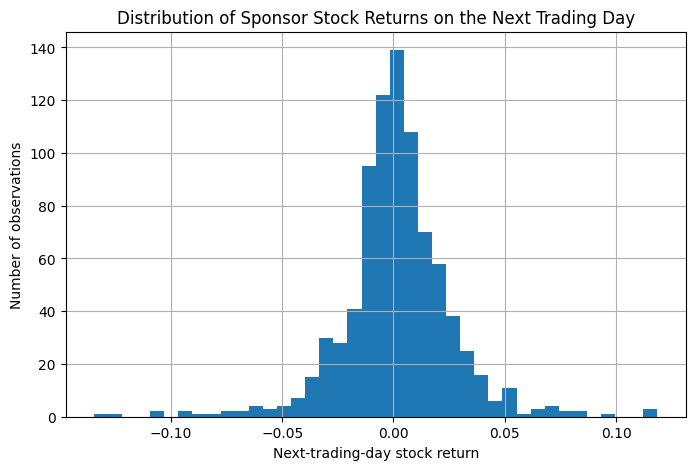

In [48]:
plt.figure(figsize=(8, 5))
regression_data["stock_return_t1"].dropna().hist(bins=40)
plt.title("Distribution of Sponsor Stock Returns on the Next Trading Day")
plt.xlabel("Next-trading-day stock return")
plt.ylabel("Number of observations")
plt.show()

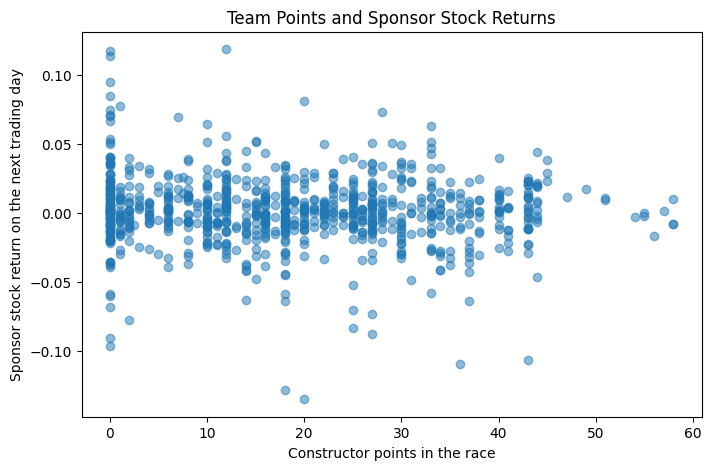

In [49]:
plt.figure(figsize=(8, 5))
plt.scatter(regression_data["team_points"], regression_data["stock_return_t1"], alpha=0.5)
plt.title("Team Points and Sponsor Stock Returns")
plt.xlabel("Constructor points in the race")
plt.ylabel("Sponsor stock return on the next trading day")
plt.show()

## 11. Regression analysis

The first model is intentionally simple. The second and third models add market controls and additional F1 performance variables.


In [50]:
def run_ols(df, y_col, x_cols):
    model_df = df[[y_col] + x_cols].dropna().copy()
    y = model_df[y_col]
    X = sm.add_constant(model_df[x_cols])
    model = sm.OLS(y, X).fit(cov_type="HC1")
    return model, model_df

model_1, model_1_df = run_ols(regression_data, "stock_return_t1", ["win"])
model_2, model_2_df = run_ols(regression_data, "stock_return_t1", ["win", "market_return_t1", "vix_level_t1"])
model_3_cols = ["win", "podium", "team_points", "market_return_t1", "vix_level_t1"]
model_3, model_3_df = run_ols(regression_data, "stock_return_t1", model_3_cols)

print(model_1.summary())
print(model_2.summary())
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:        stock_return_t1   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     4.337
Date:                Wed, 17 Jun 2026   Prob (F-statistic):             0.0376
Time:                        02:45:08   Log-Likelihood:                 1932.8
No. Observations:                 848   AIC:                            -3862.
Df Residuals:                     846   BIC:                            -3852.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0024      0.001      2.495      0.0

## 12. Save the analysis datasets

The output files are saved in the `outputs/` folder so they can be used later in the paper or for additional checks.


In [51]:
team_race.to_csv(OUTPUT_DIR / "team_race_performance.csv", index=False)
analysis_base.to_csv(OUTPUT_DIR / "sponsor_race_base.csv", index=False)
regression_data.to_csv(OUTPUT_DIR / "regression_dataset.csv", index=False)
summary_stats.to_csv(OUTPUT_DIR / "summary_statistics.csv")

print("Saved files:")
for file in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", file)

Saved files:
- /Users/wayne/Desktop/Exchange/f1-sponsor-stocks/outputs/regression_dataset.csv
- /Users/wayne/Desktop/Exchange/f1-sponsor-stocks/outputs/sponsor_race_base.csv
- /Users/wayne/Desktop/Exchange/f1-sponsor-stocks/outputs/summary_statistics.csv
- /Users/wayne/Desktop/Exchange/f1-sponsor-stocks/outputs/team_race_performance.csv
